<a href="https://colab.research.google.com/github/sumitkharayat/Machine-learning-work/blob/main/Comparison%20of%20Decision%20tree%20Random%20forest%20and%20Bagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier ,RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Applied ML lab/Experiment 11-12/dataset_diabetes_exp_11.csv')
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


Feature target

In [3]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature scaling

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [7]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Report:\n", classification_report(y_test, y_pred))
    print("F1 Sscore:", f1_score (y_test, y_pred))

In [8]:
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Bagging", y_test, y_pred_bag)
evaluate_model("Random Forest", y_test, y_pred_rf)


Decision Tree
Accuracy: 0.7467532467532467
Confusion Matrix:
 [[75 24]
 [15 40]]
Report:
               precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154

F1 Sscore: 0.6722689075630253

Bagging
Accuracy: 0.7402597402597403
Confusion Matrix:
 [[77 22]
 [18 37]]
Report:
               precision    recall  f1-score   support

           0       0.81      0.78      0.79        99
           1       0.63      0.67      0.65        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154

F1 Sscore: 0.6491228070175439

Random Forest
Accuracy: 0.7207792207792207
Confusion Matrix:
 [[77 22]
 [21 34]]
Report:
               preci

In [10]:
results = []

models_preds = {
    "Decision Tree": y_pred_dt,
    "Bagging": y_pred_bag,
    "Random Forest": y_pred_rf
}

for name, y_pred in models_preds.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)

           Model  Accuracy  Precision    Recall  F1 Score
0  Decision Tree  0.746753   0.625000  0.727273  0.672269
1        Bagging  0.740260   0.627119  0.672727  0.649123
2  Random Forest  0.720779   0.607143  0.618182  0.612613


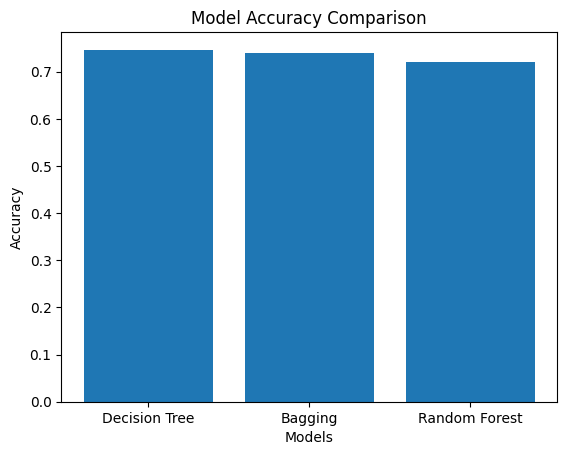

In [11]:
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

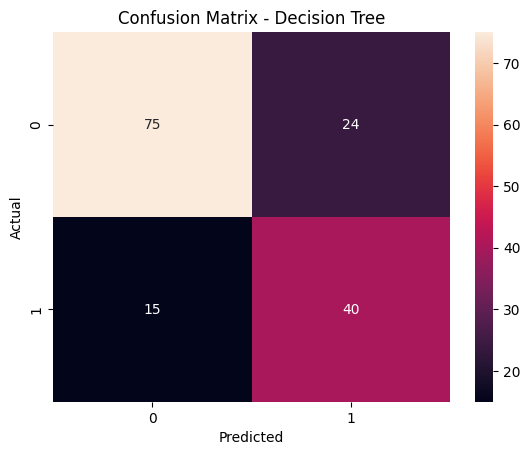

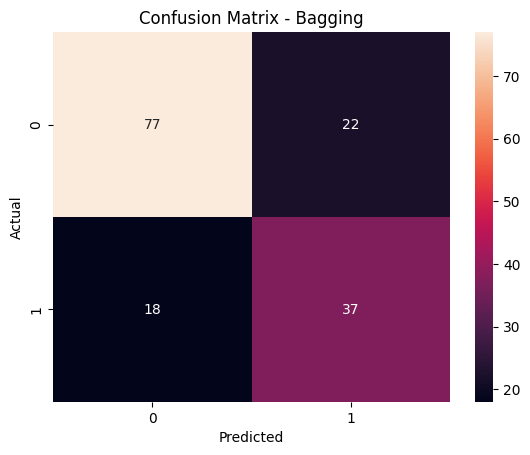

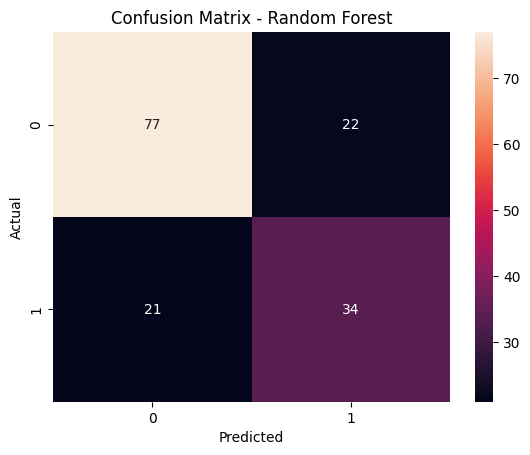

In [12]:
import seaborn as sns

models_preds = {
    "Decision Tree": y_pred_dt,
    "Bagging": y_pred_bag,
    "Random Forest": y_pred_rf
}

for name, y_pred in models_preds.items():
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()